# ３章３節２項 農業・時系列モデリング

## 概要

PAZ 衛星データを使用して、いくつかのモデルで圃場の状態推定を行います。


## 使用データ

| 項目 | 情報 |
| ---- | ---- | 
| 衛星 | PAZ |
| 観測シーンID　| `PAZ1_SAR_SSC_SL_D_SRA_20200318T165157_20200318T165159` |
| データリンク | [ESA Map Catalog](https://tpm-ds.eo.esa.int/smcat/PAZ/3/E014/N50/0/) |
| 画像クレジット| ©Hisdesat Servicios Estratégicos S.A. 2024 |

In [ ]:
import os
import numpy as np
import warnings
from glob import glob
import pandas as pd

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tqdm import tqdm
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates

import lightgbm as lgb
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score, accuracy_score

# pnada print options
pd.set_option('display.max_columns', 255)
pd.set_option('display.max_rows', 255)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', 255)


PATH_OUTPUT = os.path.join('output', '3_3_4')
os.makedirs(PATH_OUTPUT, exist_ok=True)

In [2]:
PATH_TRAIN_CSV = os.path.join('output', '204', 'train.csv')
PATH_TEST_CSV = os.path.join('output', '204', 'valid.csv')

df_train = pd.read_csv(PATH_TRAIN_CSV)
df_train = df_train.sort_values('date').reset_index(drop=True)
df_valid = pd.read_csv(PATH_TEST_CSV)
df_valid = df_valid.sort_values('date').reset_index(drop=True)
df_train.head()

,date,path_paz,name_paz,target_paz,mean_hh,std_hh,mean_hv,std_hv,mean_hh_1,std_hh_1,mean_hv_1,std_hv_1,mean_hh_2,std_hh_2,mean_hv_2,std_hv_2,mean_hh_3,std_hh_3,mean_hv_3,std_hv_3,mean_hh_4,std_hh_4,mean_hv_4,std_hv_4,mean_hh_5,std_hh_5,mean_hv_5,std_hv_5,mean_hh_6,std_hh_6,mean_hv_6,std_hv_6,mean_hh_7,std_hh_7,mean_hv_7,std_hv_7,mean_hh_8,std_hh_8,mean_hv_8,std_hv_8,mean_hh_9,std_hh_9,mean_hv_9,std_hv_9,mean_hh_10,std_hh_10,mean_hv_10,std_hv_10,mean_hh_11,std_hh_11,mean_hv_11,std_hv_11,mean_hh_12,std_hh_12,mean_hv_12,std_hv_12,mean_hh_13,std_hh_13,mean_hv_13,std_hv_13,mean_hh_14,std_hh_14,mean_hv_14,std_hv_14,mean_hh_15,std_hh_15,mean_hv_15,std_hv_15,mean_hh_16,std_hh_16,mean_hv_16,std_hv_16,mean_hh_17,std_hh_17,mean_hv_17,std_hv_17,mean_hh_18,std_hh_18,mean_hv_18,std_hv_18,mean_hh_19,std_hh_19,mean_hv_19,std_hv_19,mean_hh_20,std_hh_20,mean_hv_20,std_hv_20,mean_hh_21,std_hh_21,mean_hv_21,std_hv_21,mean_hh_22,std_hh_22,mean_hv_22,std_hv_22,mean_hh_23,std_hh_23,mean_hv_23,std_hv_23,mean_hh_24,std_hh_24,mean_hv_24,std_hv_24,mean_hh_25,std_hh_25,mean_hv_25,std_hv_25,mean_hh_26,std_hh_26,mean_hv_26,std_hv_26,mean_hh_27,std_hh_27,mean_hv_27,std_hv_27,mean_hh_28,std_hh_28,mean_hv_28,std_hv_28,mean_hh_29,std_hh_29,mean_hv_29,std_hv_29,mean_hh_30,std_hh_30,mean_hv_30,...,std_nwdi,mean_ndvi_cloud,std_ndvi_cloud,mean_nwdi_cloud,std_nwdi_cloud,mean_ndvi_1,mean_ndvi_cloud_1,mean_ndvi_2,mean_ndvi_cloud_2,mean_ndvi_3,mean_ndvi_cloud_3,mean_ndvi_4,mean_ndvi_cloud_4,mean_ndvi_5,mean_ndvi_cloud_5,mean_ndvi_6,mean_ndvi_cloud_6,mean_ndvi_7,mean_ndvi_cloud_7,mean_ndvi_8,mean_ndvi_cloud_8,mean_ndvi_9,mean_ndvi_cloud_9,mean_ndvi_10,mean_ndvi_cloud_10,mean_ndvi_11,mean_ndvi_cloud_11,mean_ndvi_12,mean_ndvi_cloud_12,mean_ndvi_13,mean_ndvi_cloud_13,mean_ndvi_14,mean_ndvi_cloud_14,mean_ndvi_15,mean_ndvi_cloud_15,mean_ndvi_16,mean_ndvi_cloud_16,mean_ndvi_17,mean_ndvi_cloud_17,mean_ndvi_18,mean_ndvi_cloud_18,mean_ndvi_19,mean_ndvi_cloud_19,mean_ndvi_20,mean_ndvi_cloud_20,mean_ndvi_21,mean_ndvi_cloud_21,mean_ndvi_22,mean_ndvi_cloud_22,mean_ndvi_23,mean_ndvi_cloud_23,mean_ndvi_24,mean_ndvi_cloud_24,mean_ndvi_25,mean_ndvi_cloud_25,mean_ndvi_26,mean_ndvi_cloud_26,mean_ndvi_27,mean_ndvi_cloud_27,mean_ndvi_28,mean_ndvi_cloud_28,mean_ndvi_29,mean_ndvi_cloud_29,mean_ndvi_30,mean_ndvi_cloud_30,mean_ndvi_31,mean_ndvi_cloud_31,mean_ndvi_32,mean_ndvi_cloud_32,mean_ndvi_33,mean_ndvi_cloud_33,mean_ndvi_34,mean_ndvi_cloud_34,mean_ndvi_35,mean_ndvi_cloud_35,mean_ndvi_36,mean_ndvi_cloud_36,mean_ndvi_37,mean_ndvi_cloud_37,mean_ndvi_38,mean_ndvi_cloud_38,mean_ndvi_39,mean_ndvi_cloud_39,mean_ndvi_40,mean_ndvi_cloud_40,mean_ndvi_41,mean_ndvi_cloud_41,mean_ndvi_42,mean_ndvi_cloud_42,mean_ndvi_43,mean_ndvi_cloud_43,mean_ndvi_44,mean_ndvi_cloud_44,mean_ndvi_45,mean_ndvi_cloud_45,mean_ndvi_46,mean_ndvi_cloud_46,mean_ndvi_47,mean_ndvi_cloud_47,mean_ndvi_48,mean_ndvi_cloud_48,mean_ndvi_49,mean_ndvi_cloud_49,mean_ndvi_50,mean_ndvi_cloud_50,mean_ndvi_51,mean_ndvi_cloud_51,mean_ndvi_52,mean_ndvi_cloud_52,mean_ndvi_53,mean_ndvi_cloud_53,mean_ndvi_54,mean_ndvi_cloud_54,mean_ndvi_55,mean_ndvi_cloud_55,mean_ndvi_56,mean_ndvi_cloud_56,mean_ndvi_57,mean_ndvi_cloud_57,mean_ndvi_58,mean_ndvi_cloud_58,mean_ndvi_59,mean_ndvi_cloud_59,mean_ndvi_60,mean_ndvi_cloud_60,step,target
0,2020-03-18,../data/paz/raster/PAZ1_SAR_SSC_SL_D_SRA_20200318T165157_20200318T165159_TC_crop_001.tif,PAZ1_SAR_SSC_SL_D_SRA_20200318T165157_20200318T165159_TC_crop_001,crop_001,9.693646,0.796159,9.573516,0.802659,9.676287,0.796473,9.561130,0.803176,9.658929,0.796786,9.548743,0.803692,9.641570,0.797100,9.536356,0.804208,9.624211,0.797414,9.523970,0.804724,9.606853,0.797727,9.511583,0.805240,9.589495,0.798041,9.499197,0.805757,9.572137,0.798355,9.486811,0.806273,9.554778,0.798669,9.474424,0.806789,9.537419,0.798982,9.462037,0.807305,9.520062,0.799296,9.449651,0.807821,9.502703,0.799610,9.437264,0.808338,9.504415,0.799631,9.427916,0.808130,9.506125,0.799653,9.418567,0.807923,9.507837,0.799674,9.409218,0.807716,9.509549,0.7996

## 特徴量整理

In [3]:
FEATURE_DAY = 30
SELECT_FEATURES = [
    'mean_hh', 'std_hh', 'mean_hv', 'std_hv',
] + [
    f'mean_hh_{day}' for day in range(1, FEATURE_DAY)
] + [
    f'mean_hv_{day}' for day in range(1, FEATURE_DAY)
] + [
    f'std_hv_{day}' for day in range(1, FEATURE_DAY)
] + [
    f'std_hv_{day}' for day in range(1, FEATURE_DAY)
] + [f'mean_ndvi_cloud_{FEATURE_DAY}']

print(f'Number of features: {len(SELECT_FEATURES)}')

# train regression model 
X_train = df_train[SELECT_FEATURES].values
y_train = df_train['mean_ndvi_cloud'].values
X_valid = df_valid[SELECT_FEATURES].values
y_valid = df_valid['mean_ndvi_cloud'].values

Number of features: 121


## 線形回帰モデル

In [4]:
model = LinearRegression(n_jobs=4)
model.fit(X_train, df_train['mean_ndvi_cloud'])
y_pred = model.predict(X_valid)
mse = root_mean_squared_error(df_valid['mean_ndvi_cloud'], y_pred)
print(f'RMSE: {mse:.3f}')

df_train['pred_linear_regression'] = model.predict(X_train)
df_valid['pred_linear_regression'] = y_pred

RMSE: 0.177


## LightGBM モデリング

In [26]:
params = {
   'num_leaves': 31,
    'max_depth': -1,
    'learning_rate': 0.05,
    'n_estimators': 100,
    'min_split_gain': 0,
    'min_child_samples': 20,
    'random_state': 2024,
}

model = lgb.LGBMRegressor(**params)
# train and validation
model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)],
          eval_metric='rmse', callbacks=[lgb.early_stopping(5, first_metric_only=True)])
y_pred = model.predict(X_valid)

mse = root_mean_squared_error(y_valid, y_pred)
print(f'\nRMSE: {mse:.3f}')

df_train['pred_lightgbm'] = model.predict(X_train)
df_valid['pred_lightgbm'] = y_pred

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001471 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 30414
[LightGBM] [Info] Number of data points in the train set: 2700, number of used features: 121
[LightGBM] [Info] Start training from score 0.601653
Training until validation scores don't improve for 5 rounds
Early stopping, best iteration is:
[32]	valid_0's rmse: 0.121109	valid_0's l2: 0.0146674
Evaluated only: rmse

RMSE: 0.121


In [6]:
df_valid[['date', 'pred_linear_regression', 'pred_lightgbm', 'target']].head()

,date,pred_linear_regression,pred_lightgbm,target
0,2020-03-18,0.731015,0.779558,crop_006
1,2020-03-18,0.366495,0.290193,crop_007
2,2020-03-19,0.722179,0.773730,crop_006
3,2020-03-19,0.363316,0.290193,crop_007
4,2020-03-20,0.714291,0.773730,crop_006


## 予測の可視化

TARGETS: ['crop_006', 'crop_007']


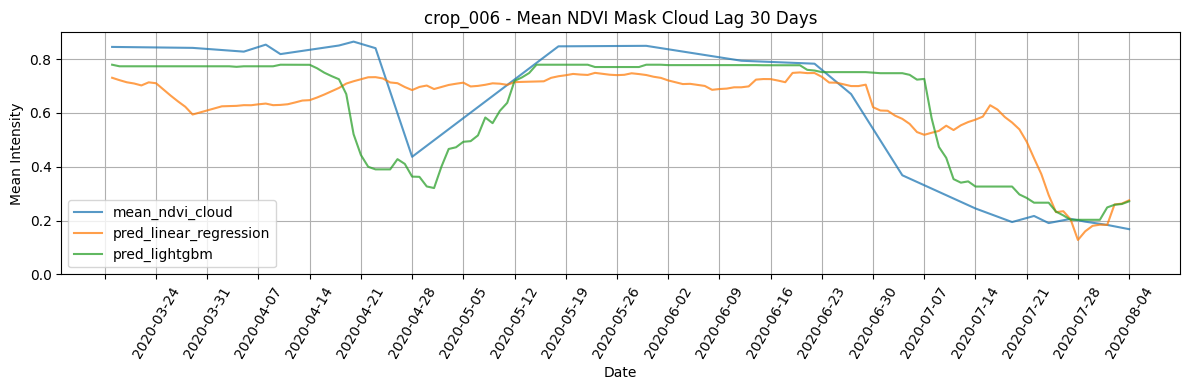

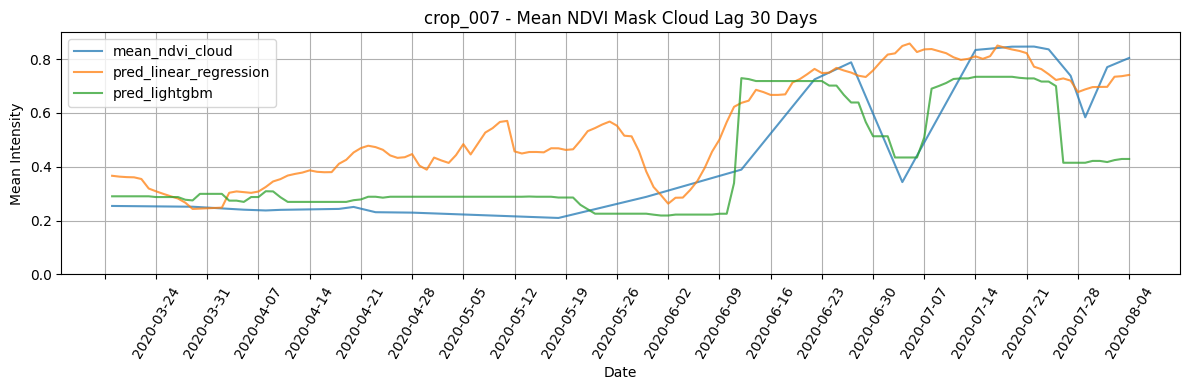

In [7]:
TARGETS = [
    f'crop_{str(i).zfill(3)}' for i in range(6, 8)
] 
print(f'TARGETS: {TARGETS}')


for k, tgt in enumerate(TARGETS):
    df_valid_tgt = df_valid[df_valid['target'] == tgt]
    # plot date
    plt.figure(figsize=(12, 4))
    plt.plot(df_valid_tgt['date'], df_valid_tgt['mean_ndvi_cloud'], label='mean_ndvi_cloud', alpha=0.75)
    plt.plot(df_valid_tgt['date'], df_valid_tgt['pred_linear_regression'], label='pred_linear_regression', alpha=0.75)
    plt.plot(df_valid_tgt['date'], df_valid_tgt['pred_lightgbm'], label='pred_lightgbm', alpha=0.75)
    plt.title(f'{tgt} - Mean NDVI Mask Cloud Lag {FEATURE_DAY} Days')
    plt.legend()
    plt.grid()
    plt.xticks(rotation=60)

    plt.ylim(0.0, 0.9)
    plt.xlabel('Date')
    plt.ylabel('Mean Intensity')
    
    # year month x label
    xaxis_ = plt.gca().xaxis
    xaxis_.set_major_locator(mdates.DayLocator(bymonthday=None, interval=7, tz=None))
    xaxis_.set_minor_formatter(DateFormatter('%y-%m'))
    
    plt.tight_layout()
    plt.savefig(os.path.join(PATH_OUTPUT, f'pred_time-series_{tgt}_mean_ndvi_cloud_day{FEATURE_DAY}.png'))
    plt.show();plt.clf();plt.close()

## 重要度の可視化

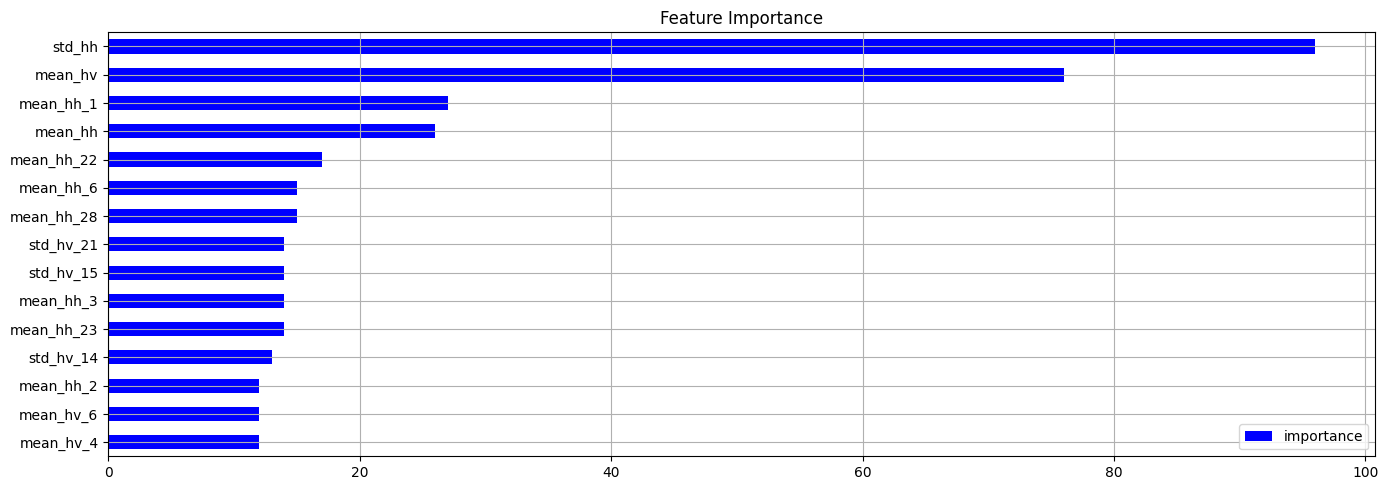

In [8]:
NUM_TOP_IMPOTANCE = 15

df_importance = pd.DataFrame(model.feature_importances_, index=SELECT_FEATURES, columns=['importance'])
df_importance = df_importance.sort_values('importance', ascending=False)[:NUM_TOP_IMPOTANCE]
df_importance = df_importance.sort_values('importance', ascending=True)

# plot feature importance
df_importance.plot(kind='barh', figsize=(14, 5), color='b')
plt.title('Feature Importance')
plt.grid()
plt.tight_layout()
plt.savefig(os.path.join(PATH_OUTPUT, f'feature_importance_day{FEATURE_DAY}.png'), dpi=100)
plt.show();plt.clf();plt.close()

## ディープラーニングモデル

In [4]:
import torch 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

time_seriese_model = 'GRU' # 'GRU', 'LSTM', 'RNN', 'DENSE'

class NDVIDataset(Dataset):
    def __init__(self, df, features, target):
        self.df = df
        self.features = features
        self.target = target
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        X = row[self.features].values
        X = X.astype(np.float32)
        y = row[self.target].astype(np.float32)
        return X, y
    
class TimeSerieseModel(nn.Module):
    
    def __init__(self, time_seriese_model='GRU', *args, **kwargs):
        super().__init__(*args, **kwargs)
        
        self.time_seriese_model = time_seriese_model
        hidden_size = 128
        
        if time_seriese_model == 'GRU':
            # GRU layer
            self.ts = nn.GRU(input_size=4, 
                            hidden_size=hidden_size, num_layers=2, 
                            batch_first=True,dropout=0.)
            
        elif time_seriese_model == 'LSTM':
            # LSTM layer
            self.ts = nn.LSTM(input_size=4, 
                                hidden_size=hidden_size, num_layers=1, 
                                batch_first=True, dropout=0.)
            
        elif time_seriese_model == 'RNN':
            # RNN layer
            self.ts = nn.RNN(input_size=4, 
                              hidden_size=hidden_size, num_layers=1, 
                              batch_first=True, dropout=0.,
                              nonlinearity='relu')
            
        if self.time_seriese_model in ['GRU', 'LSTM', 'RNN']:
            self.fcl = nn.Linear(hidden_size*FEATURE_DAY+1, 1)
            
        elif time_seriese_model == 'DENSE':
            # fully connected layer
            self.fc2 = nn.Linear(121, 128)
            self.fc3 = nn.Linear(128, 128)
            self.fc4 = nn.Linear(128, 128)
            self.fcl = nn.Linear(128, 1)
        
    def forward(self, x):
        if self.time_seriese_model in ['GRU', 'LSTM', 'RNN']:
            # RNN layer
            B, F = x.size()
            x_ts = x[:,:len(SELECT_FEATURES)-1].view(B, FEATURE_DAY, 4) # B, Sequence, F
            x_ndvi_past = x[:,len(SELECT_FEATURES)-1] # B, 4
            out, h = self.ts(x_ts)
            x_ndvi = torch.cat([out.flatten(1), x_ndvi_past.unsqueeze(1)], dim=1) # B, hidden_size+1
            x = torch.sigmoid(self.fcl(x_ndvi)) # B, 1
            

        elif self.time_seriese_model == 'DENSE':
            # dense layer
            x1 = torch.relu(self.fc2(x.view(x.size(0), -1)))
            x2 = torch.relu(self.fc3(x1))
            x3 = torch.relu(self.fc4(x2+x1))
            xl = self.fcl(x3+x2+x1)        
            x = torch.sigmoid(xl)
            
        x = torch.squeeze(x, 1)
        return x
    
# test sample
ds = NDVIDataset(df_train, SELECT_FEATURES, 'mean_ndvi_cloud')
dl = DataLoader(ds, batch_size=32, shuffle=True)
model = TimeSerieseModel()
print(model)

for k, (X, y) in enumerate(dl):
    print(f'X: {X.shape} y: {y.shape}')
    output = model(X)
    print(f'y Hat: {output.shape}')
    break

TimeSerieseModel(
  (ts): GRU(4, 128, num_layers=2, batch_first=True)
  (fcl): Linear(in_features=3841, out_features=1, bias=True)
)
X: torch.Size([32, 121]) y: torch.Size([32])
y Hat: torch.Size([32])


In [41]:
BACTH_SIZE = 8
LEARNIG_RATE = 1e-4
EPOCHS = 30

criterion = nn.MSELoss()

time_seriese_model = 'GRU' # 'GRU', 'LSTM', 'RNN', 'DENSE'
model = TimeSerieseModel(time_seriese_model)
optimizer = optim.Adam(model.parameters(), lr=LEARNIG_RATE)
# optimizer = optim.SGD(model.parameters(), lr=LEARNIG_RATE)

ds_train = NDVIDataset(df_train, SELECT_FEATURES, 'mean_ndvi_cloud')
dl_train = DataLoader(ds_train, batch_size=BACTH_SIZE, shuffle=True)

ds_valid = NDVIDataset(df_valid, SELECT_FEATURES, 'mean_ndvi_cloud')
dl_valid = DataLoader(ds_valid, batch_size=BACTH_SIZE, shuffle=False)

loss_train, loss_valid = [], []

LOSS_BEST = 1e+10

# train loop
for epoch in tqdm(range(EPOCHS), total=EPOCHS):
    model.train()
    train_loss = 0
    for X, y in dl_train:
        optimizer.zero_grad()
        output = model(X)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(dl_train)
    loss_train.append(train_loss)
    
    model.eval()
    valid_loss = 0
    with torch.no_grad():
        for X, y in dl_valid:
            output = model(X)
            loss = criterion(output, y)
            valid_loss += loss.item()
        valid_loss /= len(dl_valid)
        loss_valid.append(valid_loss)
        
        if valid_loss < LOSS_BEST:
            LOSS_BEST = valid_loss
            torch.save(model.state_dict(), os.path.join(PATH_OUTPUT, f'{time_seriese_model}_model.pth'))
    
    print(f'Epoch {epoch} - Train Loss: {train_loss:.5f} - Valid Loss: {valid_loss:.5f}')

  3%|▎         | 1/30 [00:06<03:02,  6.28s/it]

Epoch 0 - Train Loss: 0.05618 - Valid Loss: 0.06910


  7%|▋         | 2/30 [00:12<02:54,  6.25s/it]

Epoch 1 - Train Loss: 0.05482 - Valid Loss: 0.06358


 10%|█         | 3/30 [00:18<02:48,  6.23s/it]

...

Epoch 27 - Train Loss: 0.01107 - Valid Loss: 0.01996


 97%|█████████▋| 29/30 [03:03<00:06,  6.34s/it]

Epoch 28 - Train Loss: 0.01096 - Valid Loss: 0.02756


100%|██████████| 30/30 [03:09<00:00,  6.33s/it]

Epoch 29 - Train Loss: 0.01110 - Valid Loss: 0.02192


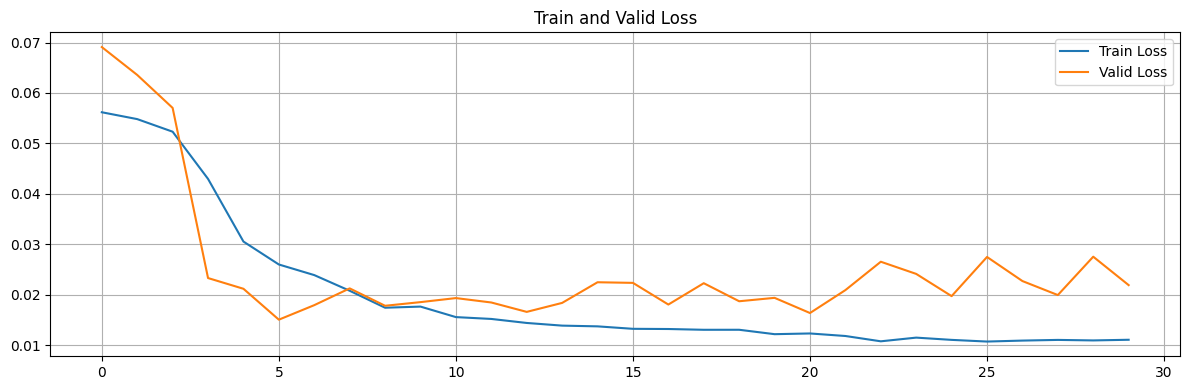

In [42]:
# plot loss
plt.figure(figsize=(12, 4))
plt.plot(loss_train, label='Train Loss')
plt.plot(loss_valid, label='Valid Loss')
plt.title('Train and Valid Loss')
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(os.path.join(PATH_OUTPUT, f'loss_train_valid_{time_seriese_model}.png'))
plt.show();plt.clf();plt.close()

## 推論処理

In [5]:
# load model
model = TimeSerieseModel(time_seriese_model)
model.load_state_dict(torch.load(os.path.join(PATH_OUTPUT, f'{time_seriese_model}_model.pth')))

# inference
model.eval()
ds_valid = NDVIDataset(df_valid, SELECT_FEATURES, 'mean_ndvi_cloud')
dl_valid = DataLoader(ds_valid, batch_size=1, shuffle=False)

preds = []

for i, (batch) in tqdm(enumerate(dl_valid), total=len(dl_valid)):
    X, y = batch
    pred = model(X)
    preds.append(pred.squeeze(0).item())

df_valid[f'pred_{time_seriese_model}'] = preds
df_valid[['date', f'pred_{time_seriese_model}', 'target']].head()

rmse = root_mean_squared_error(df_valid['mean_ndvi_cloud'], df_valid[f'pred_{time_seriese_model}'])
print(f'RMSE: {rmse:.3f}')

df_valid['rmse'] = rmse
df_valid.to_csv(os.path.join(PATH_OUTPUT, f'valid_{time_seriese_model}_rmse-{rmse:.3f}.csv'), index=False)

100%|██████████| 1080/1080 [00:03<00:00, 292.65it/s]


RMSE: 0.123


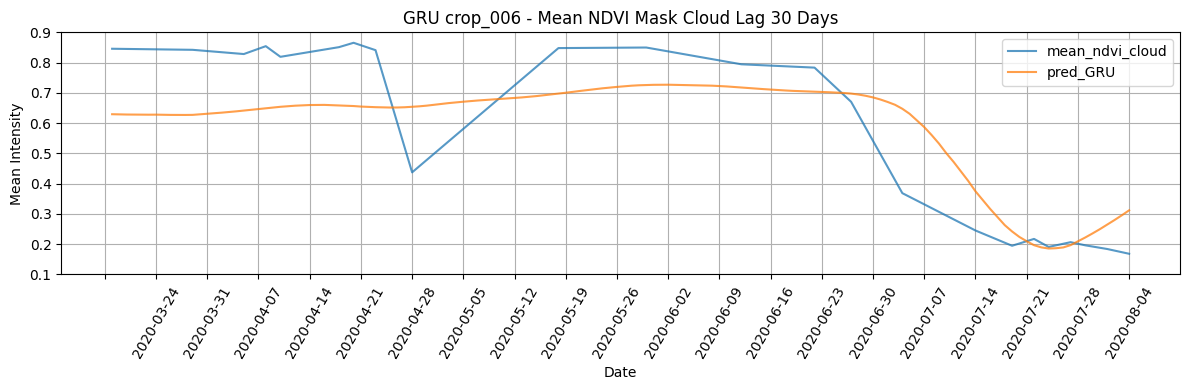

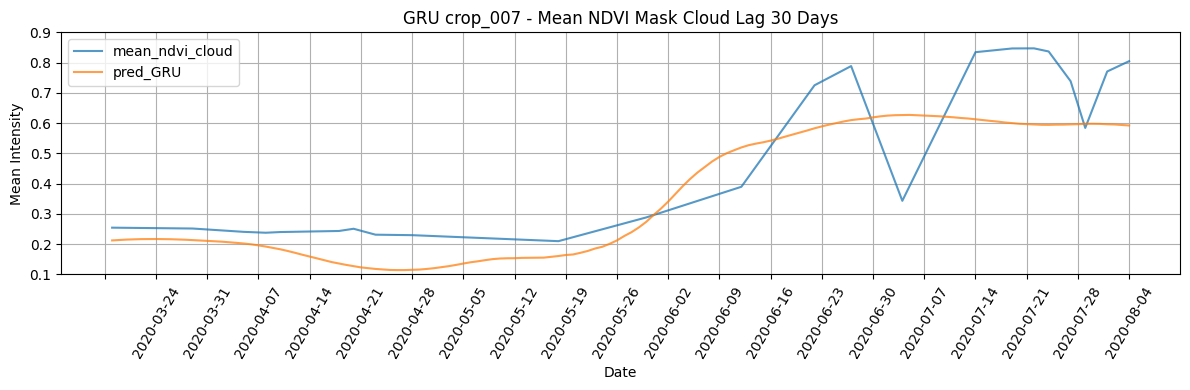

In [8]:
TARGETS = [
    f'crop_{str(i).zfill(3)}' for i in range(6, 8)
] 

for k, tgt in enumerate(TARGETS):
    df_valid_tgt = df_valid[df_valid['target'] == tgt]
    # plot date
    plt.figure(figsize=(12, 4))
    plt.plot(df_valid_tgt['date'], df_valid_tgt['mean_ndvi_cloud'], label='mean_ndvi_cloud', alpha=0.75)
    plt.plot(df_valid_tgt['date'], df_valid_tgt[f'pred_{time_seriese_model}'], 
             label=f'pred_{time_seriese_model}', alpha=0.75)
    plt.title(f'{time_seriese_model} {tgt} - Mean NDVI Mask Cloud Lag {FEATURE_DAY} Days')
    plt.legend()
    plt.grid()
    plt.xticks(rotation=60)

    plt.ylim(0.1, 0.9)
    plt.xlabel('Date')
    plt.ylabel('Mean Intensity')
    
    # year month x label
    xaxis_ = plt.gca().xaxis
    xaxis_.set_major_locator(mdates.DayLocator(bymonthday=None, interval=7, tz=None))
    xaxis_.set_minor_formatter(DateFormatter('%y-%m'))
    
    plt.tight_layout()
    plt.savefig(os.path.join(PATH_OUTPUT, f'pred_{time_seriese_model}_{tgt}_mean_ndvi_cloud_day{FEATURE_DAY}.png'))
    plt.show();plt.clf();plt.close()

##　圃場の状態推定のシミュレーション

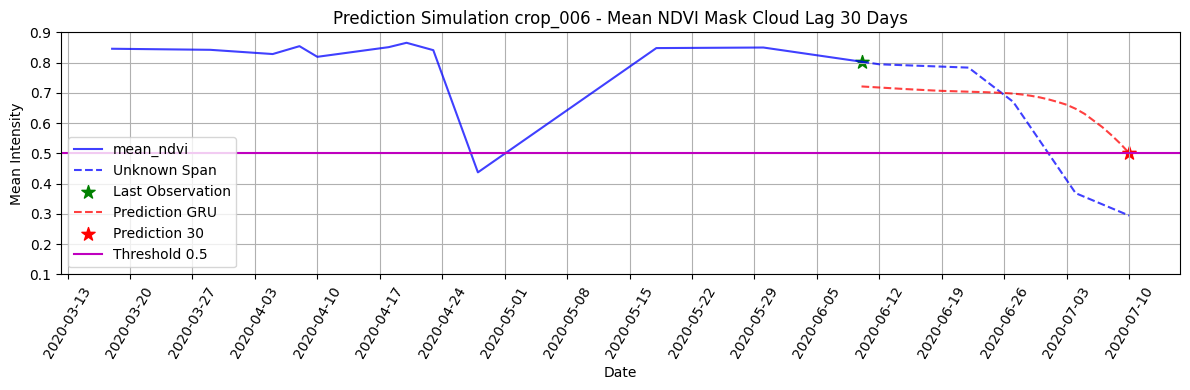

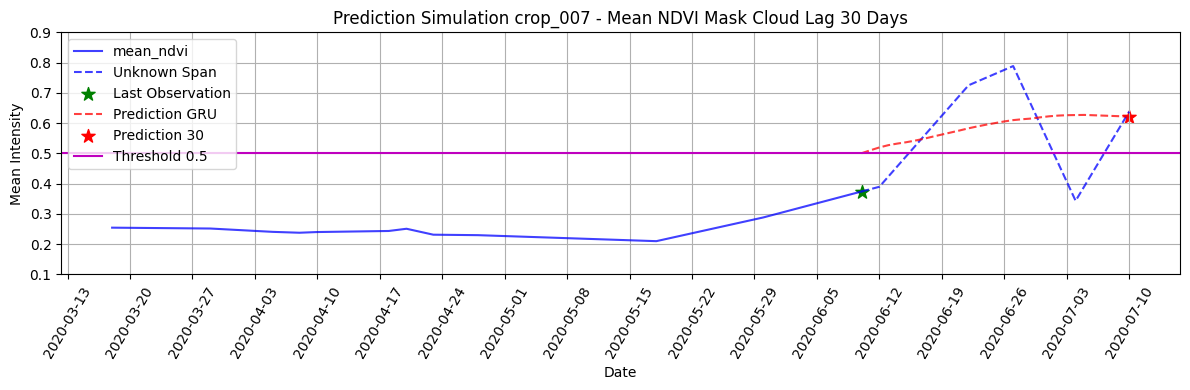

In [10]:
import datetime

date_exp = '2020-07-10'
date_exp = datetime.datetime.strptime(date_exp, '%Y-%m-%d')
date_exp_30day = date_exp - datetime.timedelta(days=FEATURE_DAY)
df_valid['date'] = pd.to_datetime(df_valid['date'])
df_valid_past = df_valid[df_valid['date'] <= date_exp_30day]
df_valid_exp = df_valid[df_valid['date'] <= date_exp]
df_valid_exp_30day = df_valid_exp[(df_valid_exp['date'] >= date_exp_30day) & (df_valid_exp['date'] <= date_exp)]

for k, tgt in enumerate(TARGETS):
    
    df_valid_exp_tgt = df_valid_past[df_valid_past['target'] == tgt]
    df_valid_exp_3day_tgt = df_valid_exp_30day[df_valid_exp_30day['target'] == tgt]
    value_gt = df_valid_exp_3day_tgt['mean_ndvi_cloud'].values[0]
    value_pred = df_valid_exp_3day_tgt[f'pred_{time_seriese_model}'].values[-1]
    
    plt.figure(figsize=(12, 4))
    
    # plot past
    plt.plot(df_valid_exp_tgt['date'], df_valid_exp_tgt['mean_ndvi_cloud'], 
             label='mean_ndvi', alpha=0.75, color='b')
    # plot exp span
    # ndvi cloud
    plt.plot(df_valid_exp_3day_tgt['date'], df_valid_exp_3day_tgt['mean_ndvi_cloud'], 
             label='Unknown Span', alpha=0.75, color='b', linestyle='--')
    plt.scatter(date_exp_30day, value_gt, label=f'Last Observation', color='g', s=100, marker='*')
    # prediction
    plt.plot(df_valid_exp_3day_tgt['date'], df_valid_exp_3day_tgt[f'pred_{time_seriese_model}'], 
             label=f'Prediction {time_seriese_model}', alpha=0.75, color='r', linestyle='--')
    plt.scatter(date_exp, value_pred, label=f'Prediction {FEATURE_DAY}', color='r', s=100, marker='*')
    
    # plot line 0.5
    plt.axhline(y=0.5, color='m', linestyle='-', label='Threshold 0.5')
    
    plt.title(f'Prediction Simulation {tgt} - Mean NDVI Mask Cloud Lag {FEATURE_DAY} Days')
    plt.legend()
    plt.grid()
    plt.xticks(rotation=60)

    plt.ylim(0.1, 0.9)
    plt.xlabel('Date')
    plt.ylabel('Mean Intensity')
    
    # year month x label
    xaxis_ = plt.gca().xaxis
    xaxis_.set_major_locator(mdates.DayLocator(bymonthday=None, interval=7, tz=None))
    xaxis_.set_minor_formatter(DateFormatter('%y-%m'))
    
    plt.tight_layout()
    plt.savefig(os.path.join(PATH_OUTPUT, f'pred_{time_seriese_model}_{tgt}_mean_ndvi_cloud_day{FEATURE_DAY}.png'))
    plt.show();plt.clf();plt.close()